# Gabi's Coloring Book — ResNet18

- **Task 1:** cartoon vs photo — supervised fine-tuning.
- **Task 2:** elephant vs house — ResNet18 embeddings + clustering inside each style + cluster alignment.
- **Output:** `/content/submission.csv`.

In [5]:
!unzip -q -o /content/custom_archive.zip -d /content/custom_archive

In [1]:
import os
import time
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from PIL import Image

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

SEED = 42
BATCH_SIZE = 32
ROOT = '/content/custom_archive'
TRAIN_CSV = '/content/train_data.csv'
TEST_CSV = '/content/test_data.csv'

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## Data

In [6]:
class ImageDataset(Dataset):
    def __init__(self, csv_file, transform=None, root_dir=ROOT):
        self.df = pd.read_csv(csv_file)
        self.transform = transform
        self.root_dir = root_dir
        self.has_labels = 'style' in self.df.columns
        self.ids = self.df['ID'].values if 'ID' in self.df.columns else np.arange(len(self.df))

        if self.has_labels:
            categories = self.df['style'].astype('category')
            self.labels = categories.cat.codes.values
            self.class_map = dict(enumerate(categories.cat.categories))
        else:
            self.labels = None
            self.class_map = {}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        rel_path = self.df.iloc[idx]['image_path']
        img_path = os.path.join(self.root_dir, rel_path.lstrip('./'))
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        if self.has_labels:
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return image, label

        return image, self.ids[idx]


train_transform = transforms.Compose([
    transforms.RandomResizedCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])

full_train_dataset = ImageDataset(TRAIN_CSV, transform=train_transform)
full_val_dataset = ImageDataset(TRAIN_CSV, transform=eval_transform)
test_dataset = ImageDataset(TEST_CSV, transform=eval_transform)

indices = torch.randperm(
    len(full_train_dataset),
    generator=torch.Generator().manual_seed(SEED),
).tolist()

split = int(0.8 * len(indices))
train_indices, val_indices = indices[:split], indices[split:]

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_val_dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}

print('classes:', full_train_dataset.class_map)
print('train:', len(train_dataset), 'val:', len(val_dataset), 'test:', len(test_dataset))

classes: {0: 'cartoon', 1: 'photo'}
train: 784 val: 197 test: 246


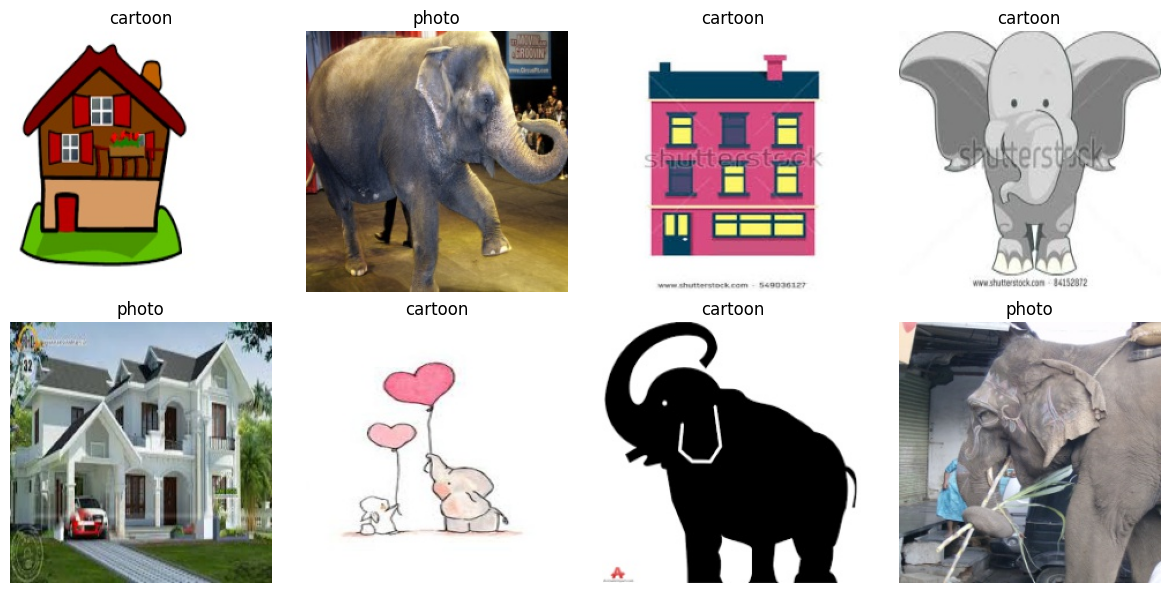

In [7]:
def show_dataset_examples(csv_file=TRAIN_CSV, n=8):
    df = pd.read_csv(csv_file)
    sample = df.sample(min(n, len(df)), random_state=SEED)

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()

    for ax, (_, row) in zip(axes, sample.iterrows()):
        path = os.path.join(ROOT, row['image_path'].lstrip('./'))
        ax.imshow(Image.open(path).convert('RGB'))
        ax.set_title(str(row.get('style', 'test')))
        ax.axis('off')

    for ax in axes[len(sample):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_dataset_examples()

## Task 1 — medium classification

In [8]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    start = time.time()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    with TemporaryDirectory() as tempdir:
        best_path = os.path.join(tempdir, 'best_model.pt')
        torch.save(model.state_dict(), best_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch + 1}/{num_epochs}')

            for phase in ('train', 'val'):
                model.train() if phase == 'train' else model.eval()
                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        preds = outputs.argmax(dim=1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += (preds == labels).sum().item()

                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects / dataset_sizes[phase]
                history[f'{phase}_loss'].append(epoch_loss)
                history[f'{phase}_acc'].append(epoch_acc)
                print(f'{phase}: loss={epoch_loss:.4f} acc={epoch_acc:.4f}')

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_path)

            print()

        model.load_state_dict(torch.load(best_path, weights_only=True))

    elapsed = time.time() - start
    print(f'best val acc: {best_acc:.4f}')
    print(f'time: {elapsed // 60:.0f}m {elapsed % 60:.0f}s')
    return model, history

In [9]:
model_task1 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features = model_task1.fc.in_features
num_classes = len(full_train_dataset.class_map)
model_task1.fc = nn.Linear(num_features, num_classes)
model_task1 = model_task1.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_task1.parameters(), lr=1e-3, momentum=0.9)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

model_task1, history = train_model(
    model_task1,
    criterion,
    optimizer,
    scheduler,
    num_epochs=10,
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 132MB/s]


Epoch 1/10
train: loss=0.3390 acc=0.8508
val: loss=0.0538 acc=1.0000

Epoch 2/10
train: loss=0.0852 acc=0.9745
val: loss=0.0246 acc=0.9949

Epoch 3/10
train: loss=0.0551 acc=0.9834
val: loss=0.0158 acc=0.9949

Epoch 4/10
train: loss=0.0374 acc=0.9898
val: loss=0.0078 acc=1.0000

Epoch 5/10
train: loss=0.0340 acc=0.9898
val: loss=0.0111 acc=0.9949

Epoch 6/10
train: loss=0.0329 acc=0.9898
val: loss=0.0069 acc=1.0000

Epoch 7/10
train: loss=0.0253 acc=0.9923
val: loss=0.0050 acc=1.0000

Epoch 8/10
train: loss=0.0285 acc=0.9936
val: loss=0.0056 acc=1.0000

Epoch 9/10
train: loss=0.0246 acc=0.9949
val: loss=0.0070 acc=1.0000

Epoch 10/10
train: loss=0.0251 acc=0.9936
val: loss=0.0050 acc=1.0000

best val acc: 1.0000
time: 0m 54s


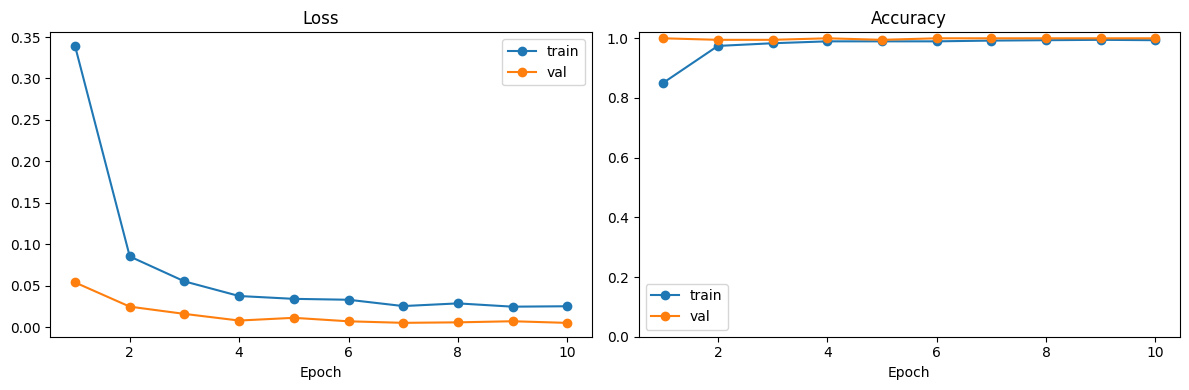

In [10]:
epochs = np.arange(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], marker='o', label='train')
axes[0].plot(epochs, history['val_loss'], marker='o', label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], marker='o', label='train')
axes[1].plot(epochs, history['val_acc'], marker='o', label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1.02)
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
model_task1.eval()
predicted_ids = []
predicted_styles = []
class_map = full_train_dataset.class_map

with torch.no_grad():
    for images, ids in test_loader:
        outputs = model_task1(images.to(device))
        preds = outputs.argmax(dim=1).cpu().numpy()
        predicted_ids.extend(ids.cpu().numpy().tolist())
        predicted_styles.extend(class_map[int(p)] for p in preds)

submission_task1 = pd.DataFrame({
    'subtaskID': 1,
    'datapointID': predicted_ids,
    'answer': predicted_styles,
})

print(submission_task1['answer'].value_counts())

answer
cartoon    146
photo      100
Name: count, dtype: int64


## Task 2 — content clustering

In [12]:
weights = models.ResNet18_Weights.IMAGENET1K_V1

feature_model = models.resnet18(weights=weights)
feature_model.fc = nn.Identity()
feature_model = feature_model.to(device).eval()

semantic_model = models.resnet18(weights=weights).to(device).eval()

task2_dataset = ImageDataset(TEST_CSV, transform=weights.transforms())
task2_loader = DataLoader(task2_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_features = []
all_logits = []
task2_ids = []

with torch.no_grad():
    for images, ids in task2_loader:
        images = images.to(device)
        features = F.normalize(feature_model(images), p=2, dim=1)
        logits = semantic_model(images)

        all_features.append(features.cpu().numpy())
        all_logits.append(logits.cpu().numpy())
        task2_ids.extend(ids.cpu().numpy().tolist())

all_features = np.concatenate(all_features)
all_logits = np.concatenate(all_logits)
task2_ids = np.asarray(task2_ids)

style_by_id = dict(zip(map(int, predicted_ids), predicted_styles))
styles = np.array([style_by_id[int(i)] for i in task2_ids])

print('features:', all_features.shape)
print(pd.Series(styles).value_counts())

features: (246, 512)
cartoon    146
photo      100
Name: count, dtype: int64


In [13]:
local_clusters = np.zeros(len(all_features), dtype=int)

for style in ('cartoon', 'photo'):
    mask = styles == style
    X = all_features[mask]
    n_components = min(32, X.shape[0] - 1, X.shape[1])
    X_reduced = PCA(n_components=n_components, random_state=SEED).fit_transform(X)

    local_clusters[mask] = KMeans(
        n_clusters=2,
        n_init=100,
        random_state=SEED,
    ).fit_predict(X_reduced)

semantic_residuals = all_logits.copy()
for style in ('cartoon', 'photo'):
    mask = styles == style
    semantic_residuals[mask] -= all_logits[mask].mean(axis=0, keepdims=True)
semantic_residuals = normalize(semantic_residuals)

prototypes = {}
for style in ('cartoon', 'photo'):
    prototypes[style] = {}
    for cluster_id in (0, 1):
        mask = (styles == style) & (local_clusters == cluster_id)
        prototype = semantic_residuals[mask].mean(axis=0)
        prototypes[style][cluster_id] = prototype / (np.linalg.norm(prototype) + 1e-8)

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))

same_score = (
    cosine(prototypes['cartoon'][0], prototypes['photo'][0])
    + cosine(prototypes['cartoon'][1], prototypes['photo'][1])
)
flip_score = (
    cosine(prototypes['cartoon'][0], prototypes['photo'][1])
    + cosine(prototypes['cartoon'][1], prototypes['photo'][0])
)

content_clusters = local_clusters.copy()
photo_mask = styles == 'photo'
if flip_score > same_score:
    content_clusters[photo_mask] = 1 - content_clusters[photo_mask]

print('same score:', round(same_score, 4))
print('flip score:', round(flip_score, 4))
print(pd.crosstab(pd.Series(styles, name='style'),
                  pd.Series(content_clusters, name='cluster')))

same score: -0.9169
flip score: 0.9161
cluster   0   1
style          
cartoon  89  57
photo    42  58


### Task 2 visualization

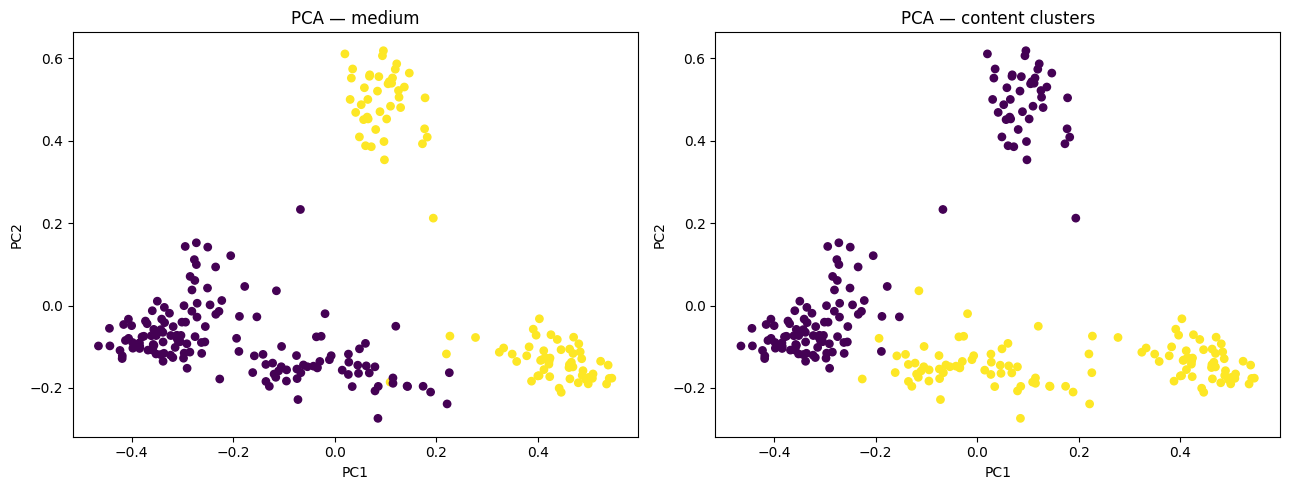

In [14]:
X_vis = PCA(n_components=2, random_state=SEED).fit_transform(all_features)
style_numeric = np.array([0 if s == 'cartoon' else 1 for s in styles])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=style_numeric, s=28)
axes[0].set_title('PCA — medium')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_vis[:, 0], X_vis[:, 1], c=content_clusters, s=28)
axes[1].set_title('PCA — content clusters')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

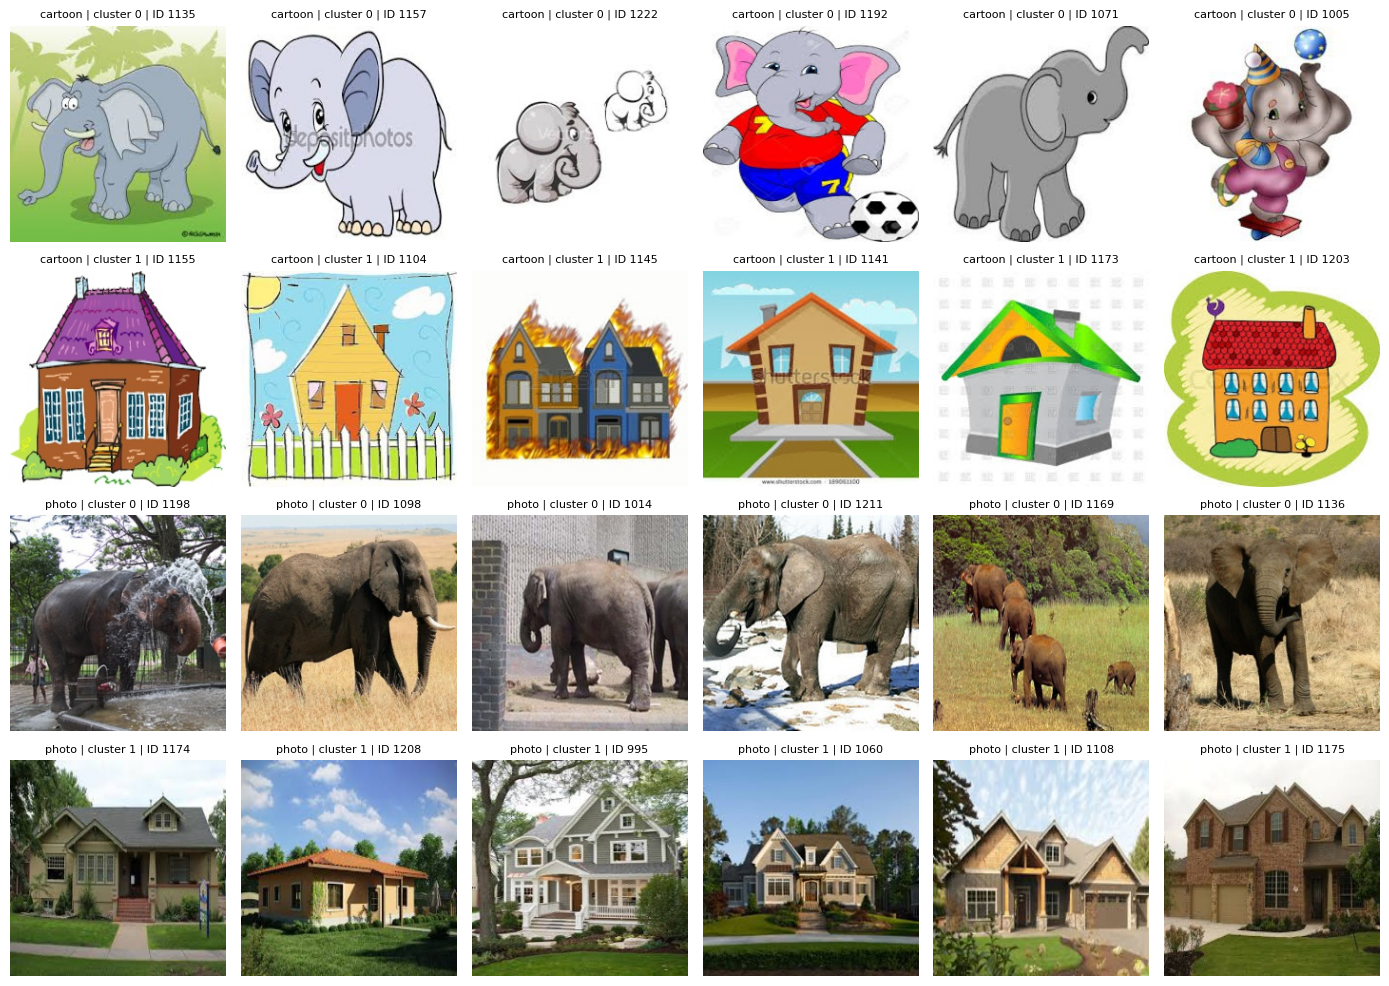

In [15]:
test_df = pd.read_csv(TEST_CSV)
path_by_id = dict(zip(test_df['ID'], test_df['image_path']))
groups = [('cartoon', 0), ('cartoon', 1), ('photo', 0), ('photo', 1)]
rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(4, 6, figsize=(14, 10))

for row, (style, cluster_id) in enumerate(groups):
    indices = np.where((styles == style) & (content_clusters == cluster_id))[0]
    selected = rng.choice(indices, size=min(6, len(indices)), replace=False)

    for col, ax in enumerate(axes[row]):
        ax.axis('off')
        if col >= len(selected):
            continue

        idx = selected[col]
        image_id = int(task2_ids[idx])
        rel_path = path_by_id[image_id]
        path = os.path.join(ROOT, rel_path.lstrip('./'))
        ax.imshow(Image.open(path).convert('RGB'))
        ax.set_title(f'{style} | cluster {cluster_id} | ID {image_id}', fontsize=8)

plt.tight_layout()
plt.show()

## Submission

In [16]:
task2_answers = np.where(content_clusters == 0, 'elephant', 'house')

submission_task2 = pd.DataFrame({
    'subtaskID': 2,
    'datapointID': task2_ids,
    'answer': task2_answers,
})

submission = pd.concat([submission_task1, submission_task2], ignore_index=True)
submission = submission.sort_values(['subtaskID', 'datapointID']).reset_index(drop=True)
submission.to_csv('/content/submission.csv', index=False)

assert list(submission.columns) == ['subtaskID', 'datapointID', 'answer']
assert len(submission_task1) == len(submission_task2)
assert set(submission_task1['answer']) <= {'cartoon', 'photo'}
assert set(submission_task2['answer']) <= {'elephant', 'house'}

print('shape:', submission.shape)
print(submission.groupby(['subtaskID', 'answer']).size())
submission.head()

shape: (492, 3)
subtaskID  answer  
1          cartoon     146
           photo       100
2          elephant    131
           house       115
dtype: int64


,subtaskID,datapointID,answer
0,1,981,cartoon
1,1,982,photo
2,1,983,cartoon
3,1,984,photo
4,1,985,photo
